In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv('traffic-count-data.csv')

In [3]:
# Isolating the data we'll use to determine which neighboorhood has the best traffic - average speed limit, average speed, and % of drivers speeding.
filteredData = data[['neighborhood','speed_limit','median_speed','percent_over_limit']]
groupedData = filteredData.groupby('neighborhood').agg({'speed_limit': 'mean','median_speed': 'mean','percent_over_limit': 'mean'}).round(3).dropna()
print(groupedData)

                  speed_limit  median_speed  percent_over_limit
neighborhood                                                   
Allegheny Center       25.000        27.000              65.000
Allegheny West         25.000        20.000              11.000
Arlington              25.000        26.500              61.500
Beechview              25.000        26.667              59.000
Bloomfield             27.727        22.467              24.556
...                       ...           ...                 ...
Summer Hill            25.000        26.000              55.000
Upper Hill             25.000        22.767              24.333
West Oakland           25.000        23.000              28.000
Westwood               31.667        36.500              59.500
Windgap                28.333        29.000              33.667

[61 rows x 3 columns]


In [4]:
# Turning average speed limit and average speed into a score from 0-100, based on what % of the speed limit the average driver is driving at.
groupedData['speed_diff'] = groupedData['median_speed'] / groupedData['speed_limit']
groupedData['percent_diff'] = (abs(((groupedData['speed_diff'] * 100)) - 100).round(3).astype(str))
groupedData['speed_score'] = 100 - groupedData['percent_diff'].astype(float)

# Turning % of drivers speeding into a score from 0-100, based on how low the % is.
groupedData['speeding_score'] = abs(100 - groupedData['percent_over_limit'])
print(groupedData)

                  speed_limit  median_speed  percent_over_limit  speed_diff  \
neighborhood                                                                  
Allegheny Center       25.000        27.000              65.000    1.080000   
Allegheny West         25.000        20.000              11.000    0.800000   
Arlington              25.000        26.500              61.500    1.060000   
Beechview              25.000        26.667              59.000    1.066680   
Bloomfield             27.727        22.467              24.556    0.810293   
...                       ...           ...                 ...         ...   
Summer Hill            25.000        26.000              55.000    1.040000   
Upper Hill             25.000        22.767              24.333    0.910680   
West Oakland           25.000        23.000              28.000    0.920000   
Westwood               31.667        36.500              59.500    1.152619   
Windgap                28.333        29.000         

In [5]:
# Trimming the data into just our original metrics and our scores.
filteredGroupData = groupedData[['speed_score', 'speeding_score','speed_limit', 'median_speed', 'percent_over_limit']].copy()
print(filteredGroupData)

                  speed_score  speeding_score  speed_limit  median_speed  \
neighborhood                                                               
Allegheny Center       92.000          35.000       25.000        27.000   
Allegheny West         80.000          89.000       25.000        20.000   
Arlington              94.000          38.500       25.000        26.500   
Beechview              93.332          41.000       25.000        26.667   
Bloomfield             81.029          75.444       27.727        22.467   
...                       ...             ...          ...           ...   
Summer Hill            96.000          45.000       25.000        26.000   
Upper Hill             91.068          75.667       25.000        22.767   
West Oakland           92.000          72.000       25.000        23.000   
Westwood               84.738          40.500       31.667        36.500   
Windgap                97.646          66.333       28.333        29.000   

           

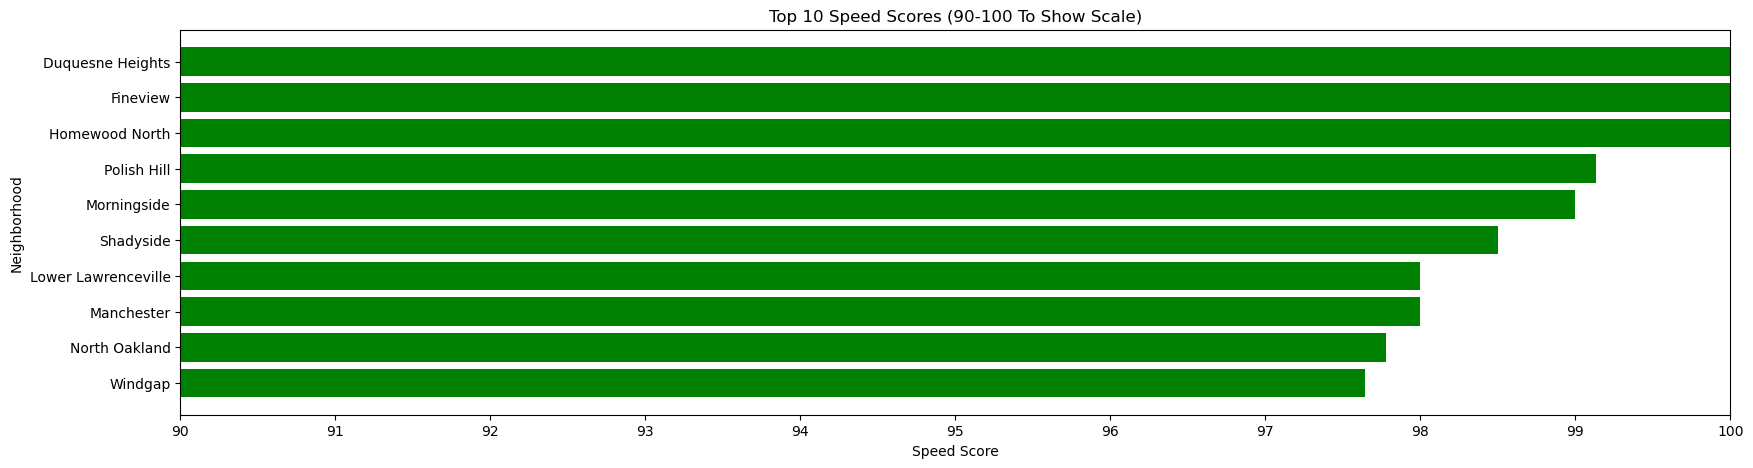

In [12]:
# Displaying the 10 best speed scores
speedSortedDesc = filteredGroupData.sort_values(by='speed_score', ascending=False).reset_index()
topTenSpeed = speedSortedDesc.head(10)

plt.figure(figsize=(20,5))
plt.barh(topTenSpeed["neighborhood"], topTenSpeed["speed_score"], color='green')
plt.ylabel("Neighborhood")
plt.xlabel("Speed Score")
plt.title("Top 10 Speed Scores (90-100 To Show Scale)")
plt.xlim(90,100)
plt.xticks(range(90, 101, 1))
plt.gca().invert_yaxis()
plt.show()

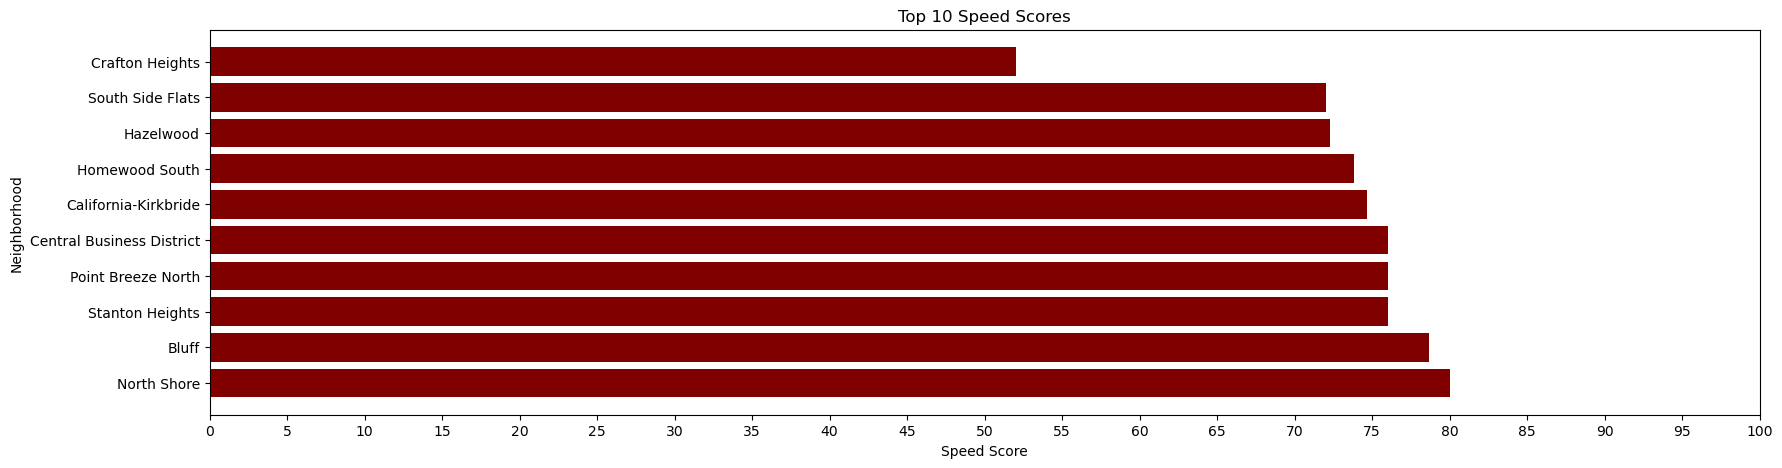

In [15]:
# Displaying the 10 worst speed scores
speedSortedAsc = filteredGroupData.sort_values(by='speed_score').reset_index()
botTenSpeed = speedSortedAsc.head(10)

plt.figure(figsize=(20,5))
plt.barh(botTenSpeed["neighborhood"], botTenSpeed["speed_score"], color='maroon')
plt.ylabel("Neighborhood")
plt.xlabel("Speed Score")
plt.title("Top 10 Speed Scores")
plt.xlim(0,100)
plt.xticks(range(0, 101, 5))
plt.gca().invert_yaxis()
plt.show()

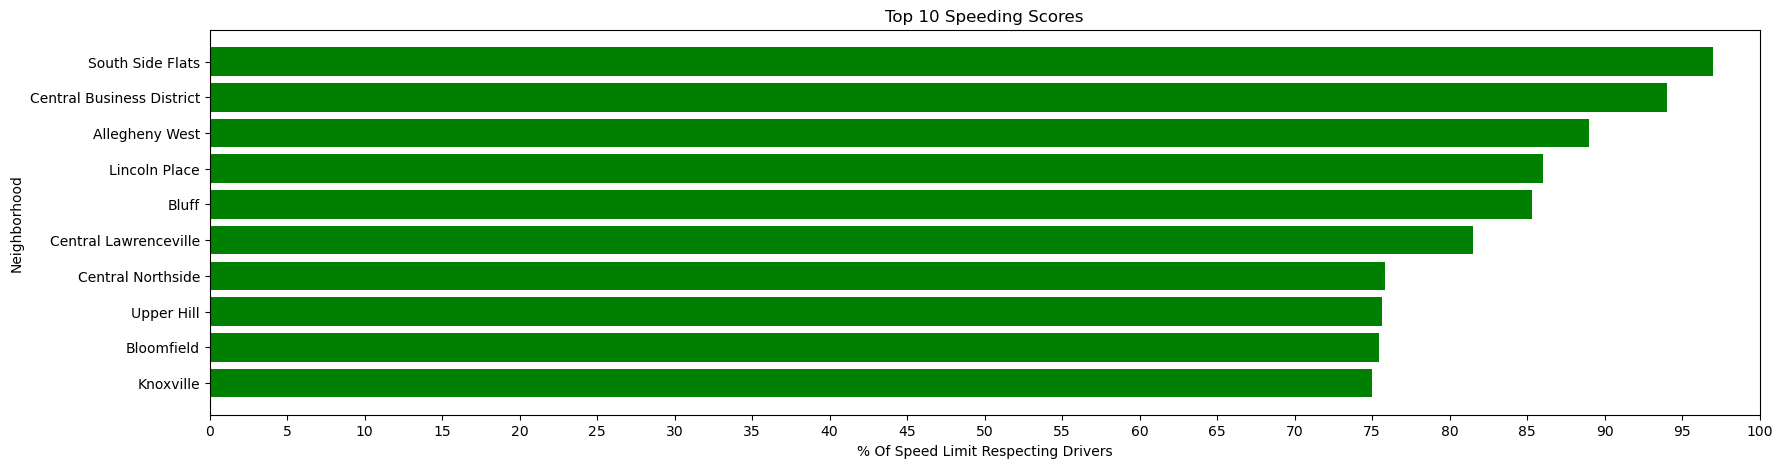

In [16]:
# Displaying the 10 best speeding scores
speedingSortedDesc = filteredGroupData.sort_values(by='speeding_score', ascending=False).reset_index()
topTenSpeeding = speedingSortedDesc.head(10)

plt.figure(figsize=(20,5))
plt.barh(topTenSpeeding["neighborhood"], topTenSpeeding["speeding_score"], color='green')
plt.ylabel("Neighborhood")
plt.xlabel("% Of Speed Limit Respecting Drivers")
plt.title("Top 10 Speeding Scores")
plt.xlim(0,100)
plt.xticks(range(0, 101, 5))
plt.gca().invert_yaxis()
plt.show()

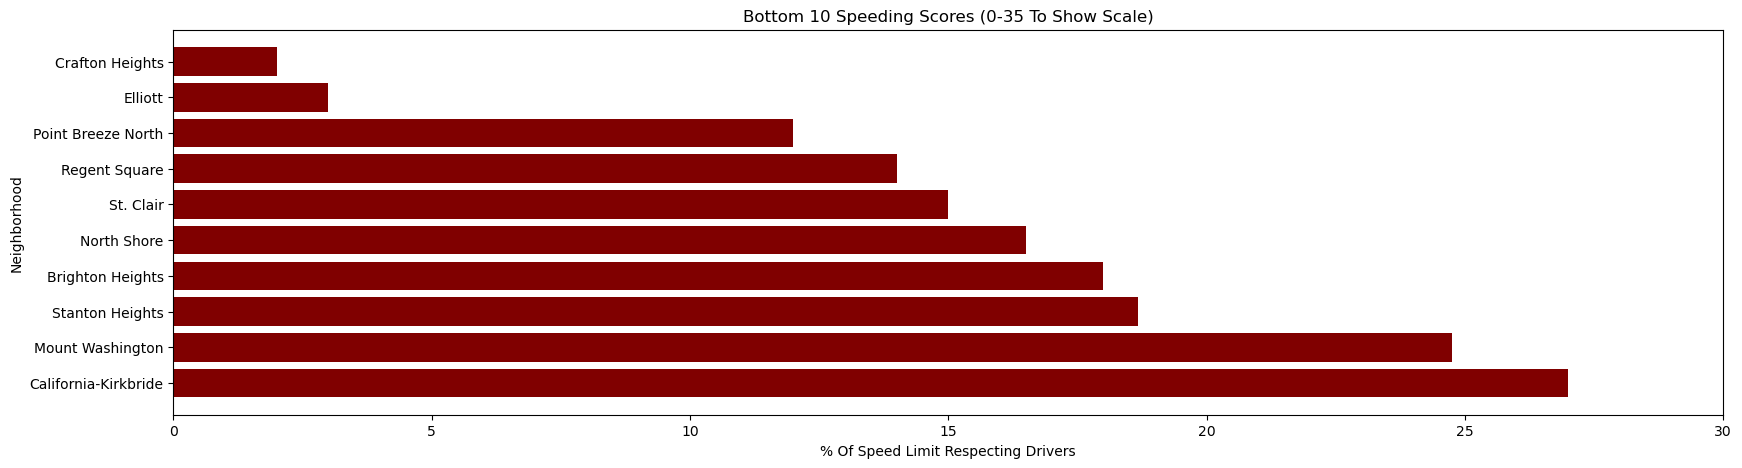

In [17]:
# Displaying the 10 worst speeding scores
speedingSortedAsc = filteredGroupData.sort_values(by='speeding_score').reset_index()
botTenSpeeding = speedingSortedAsc.head(10)

plt.figure(figsize=(20,5))
plt.barh(botTenSpeeding["neighborhood"], botTenSpeeding["speeding_score"], color='maroon')
plt.ylabel("Neighborhood")
plt.xlabel("% Of Speed Limit Respecting Drivers")
plt.title("Bottom 10 Speeding Scores (0-35 To Show Scale)")
plt.xlim(0,30)
plt.xticks(range(0, 31, 5))
plt.gca().invert_yaxis()
plt.show()

In [18]:
# Finding the combined scores
filteredGroupData.reset_index()
filteredGroupData['combined_score'] = ((filteredGroupData['speed_score'] + filteredGroupData['speeding_score'])/2).round(3)
print(filteredGroupData.sort_values(by='combined_score', ascending=False))

                           speed_score  speeding_score  speed_limit  \
neighborhood                                                          
Knoxville                       96.000          75.000       25.000   
Central Business District       76.000          94.000       25.000   
Perry South                     95.295          74.333       28.333   
South Side Flats                72.000          97.000       25.000   
Allegheny West                  80.000          89.000       25.000   
...                                ...             ...          ...   
Elliott                         92.000           3.000       25.000   
Stanton Heights                 76.000          18.667       25.000   
Regent Square                   80.000          14.000       25.000   
Point Breeze North              76.000          12.000       25.000   
Crafton Heights                 52.000           2.000       25.000   

                           median_speed  percent_over_limit  combined_score 

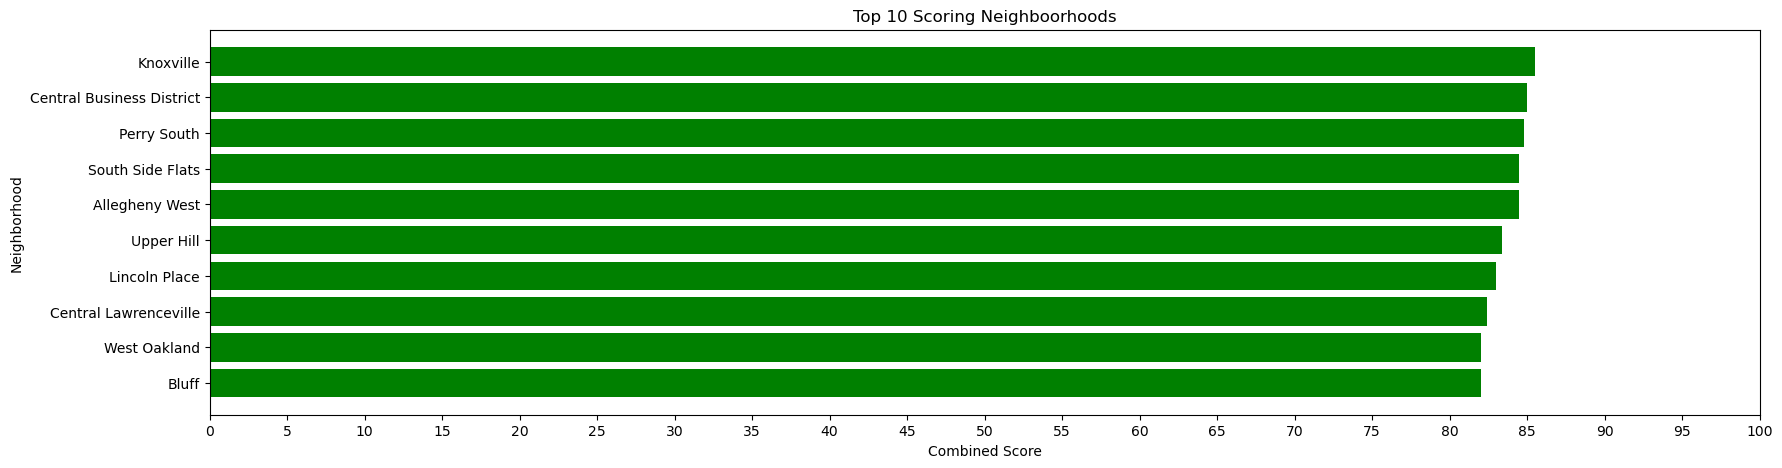

In [34]:
# Displaying the 10 best combined scores
scoreSortedDesc = filteredGroupData.sort_values(by='combined_score', ascending=False).reset_index()
topTenScore = scoreSortedDesc.head(10)

plt.figure(figsize=(20,5))
plt.barh(topTenScore["neighborhood"], topTenScore["combined_score"], color='green')
plt.ylabel("Neighborhood")
plt.xlabel("Combined Score")
plt.title("Top 10 Scoring Neighboorhoods")
plt.xlim(0,100)
plt.xticks(range(0, 101, 5))
plt.gca().invert_yaxis()
plt.show()

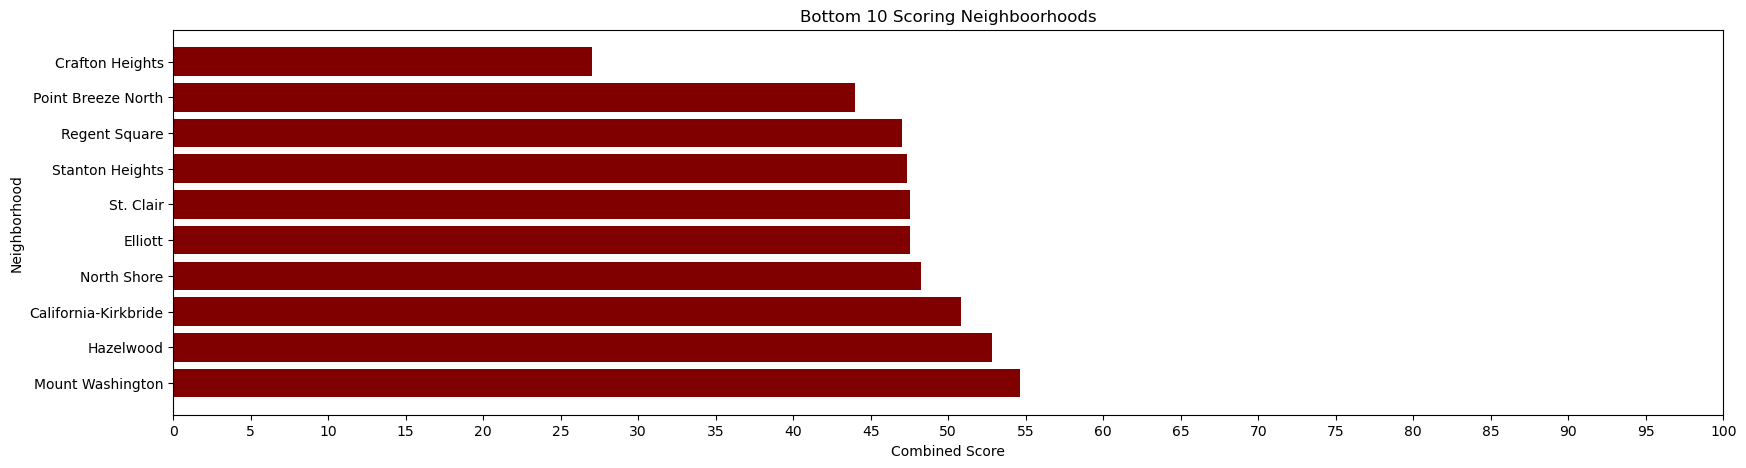

In [39]:
# Displaying the 10 best combined scores
scoreSortedAsc = filteredGroupData.sort_values(by='combined_score').reset_index()
botTenScore = scoreSortedAsc.head(10)

plt.figure(figsize=(20,5))
plt.barh(botTenScore["neighborhood"], botTenScore["combined_score"], color='maroon')
plt.ylabel("Neighborhood")
plt.xlabel("Combined Score")
plt.title("Bottom 10 Scoring Neighboorhoods")
plt.xlim(0,100)
plt.xticks(range(0, 101, 5))
plt.gca().invert_yaxis()
plt.show()

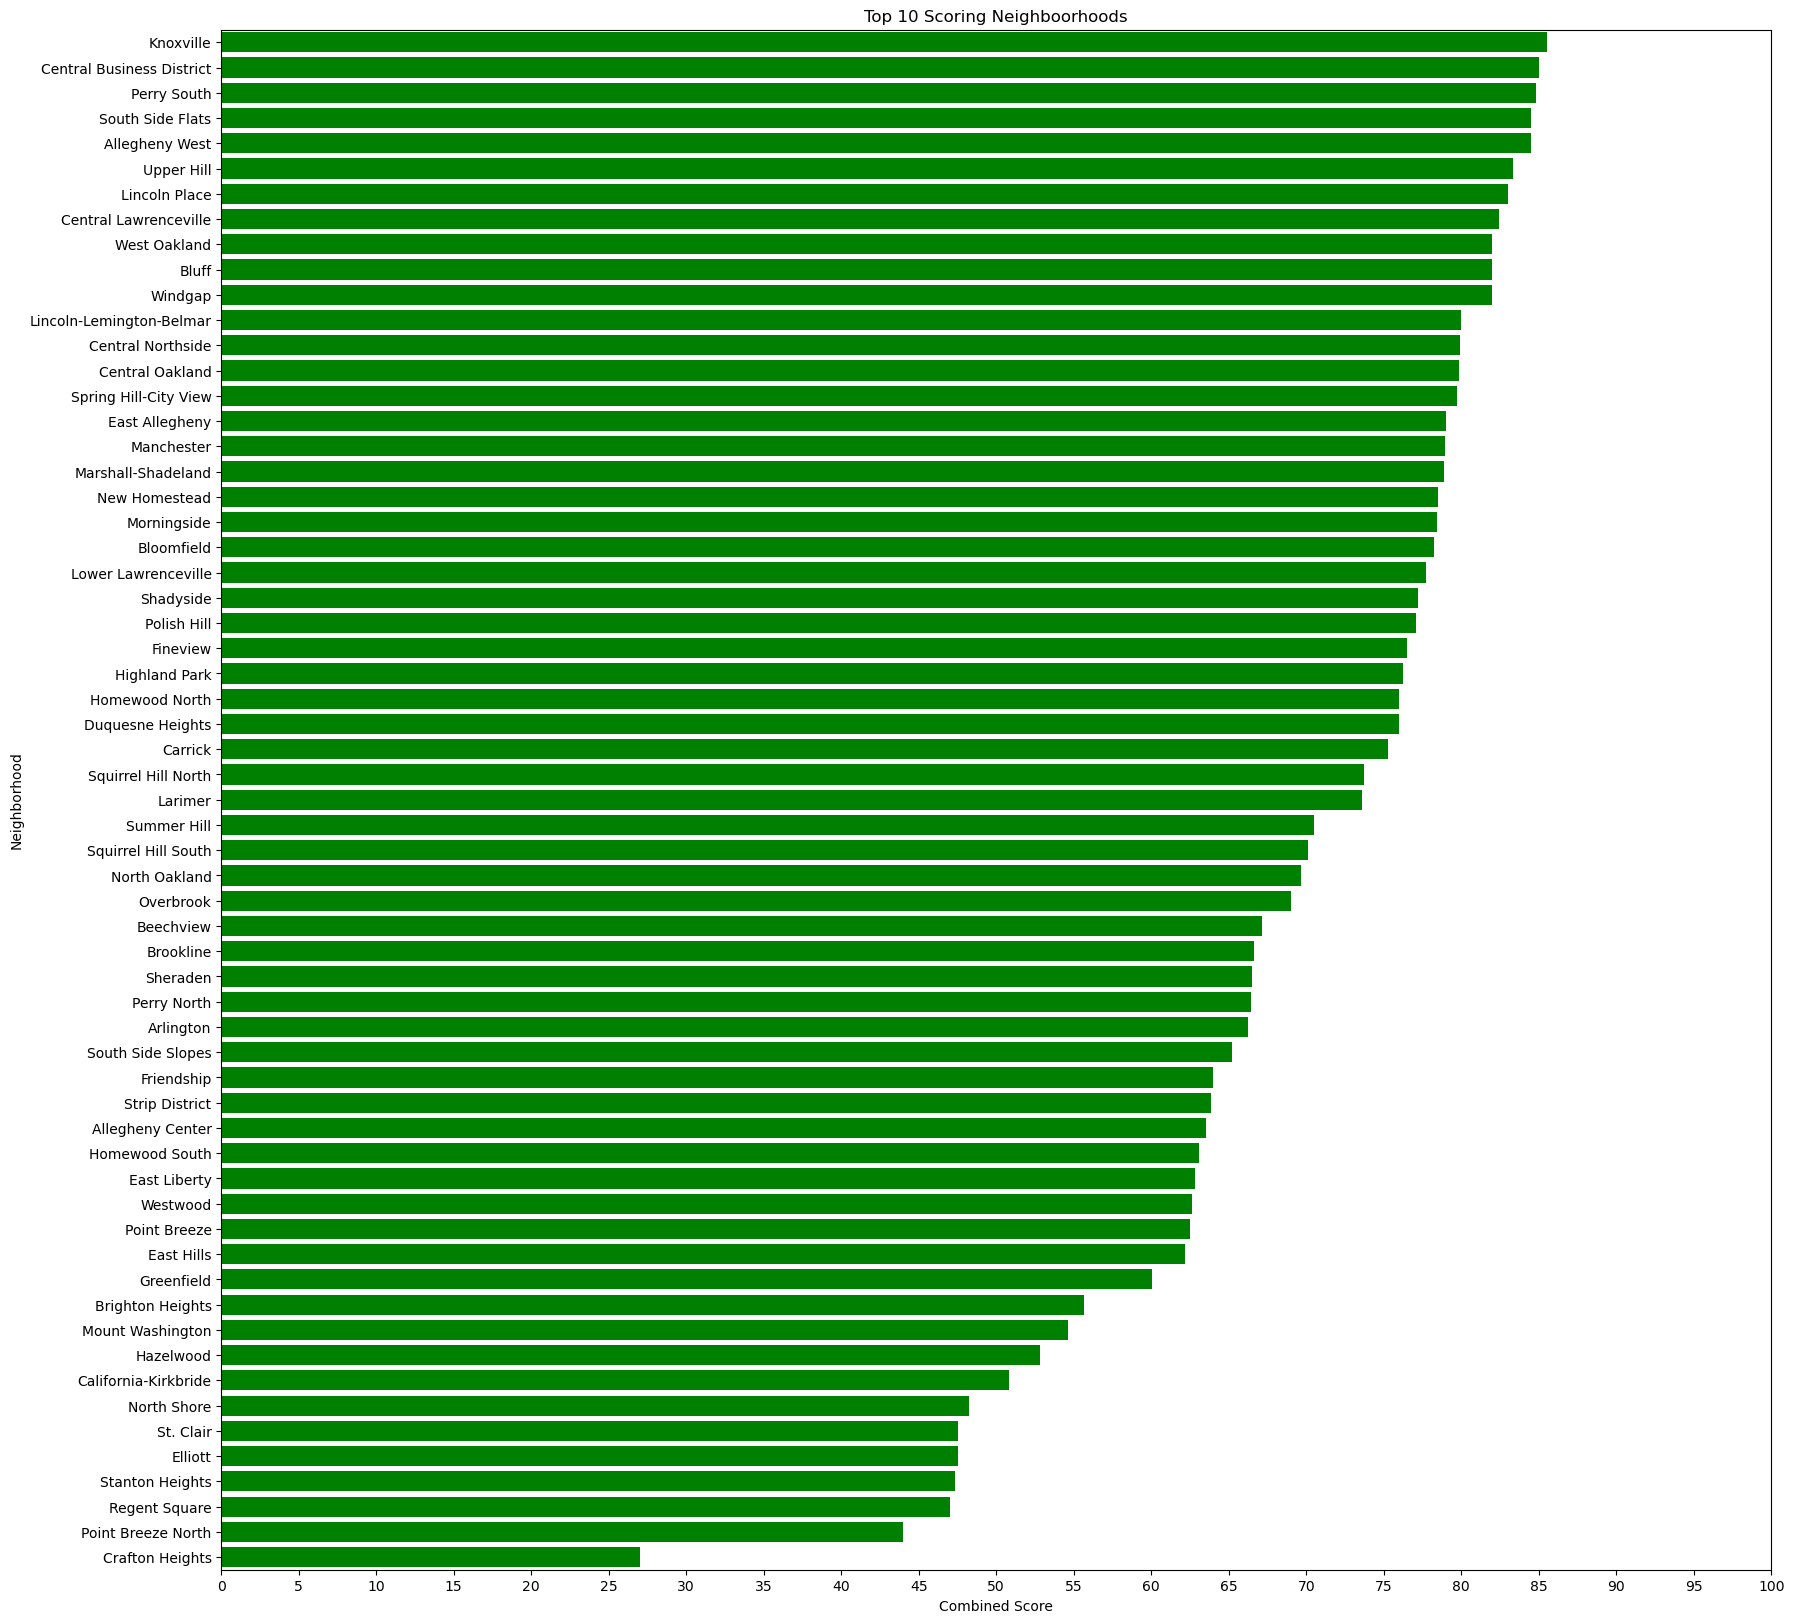

neighborhood
Knoxville                    85.500
Central Business District    85.000
Perry South                  84.814
South Side Flats             84.500
Allegheny West               84.500
Upper Hill                   83.368
Lincoln Place                83.000
Central Lawrenceville        82.416
West Oakland                 82.000
Bluff                        82.000
Windgap                      81.989
Lincoln-Lemington-Belmar     80.000
Central Northside            79.916
Central Oakland              79.832
Spring Hill-City View        79.750
East Allegheny               79.000
Manchester                   78.944
Marshall-Shadeland           78.911
New Homestead                78.500
Morningside                  78.438
Bloomfield                   78.236
Lower Lawrenceville          77.750
Shadyside                    77.216
Polish Hill                  77.066
Fineview                     76.500
Highland Park                76.267
Homewood North               76.000
Duquesne Height

In [32]:
# Displaying every neighborhood's combined score
scoreSortedDesc = filteredGroupData.sort_values(by='combined_score', ascending=False).reset_index()

plt.figure(figsize=(20,20))
plt.barh(scoreSortedDesc["neighborhood"], scoreSortedDesc["combined_score"], color='green')
plt.ylabel("Neighborhood")
plt.xlabel("Combined Score")
plt.title("Top 10 Scoring Neighboorhoods")
plt.xlim(0,100)
plt.xticks(range(0, 101, 5))
plt.ylim(-0.5, len(scoreSortedDesc) - 0.5)
plt.gca().invert_yaxis()
plt.show()

# Listing every neighborhood's combined score
with pd.option_context('display.max_rows', None):
    print(filteredGroupData['combined_score'].sort_values(ascending=False).to_string())